# Custom CNN Baseline for Binary Image Classification

## Overview
This notebook implements a custom CNN architecture with residual blocks and multi-scale feature extraction for binary image classification on an imbalanced dataset. The model uses weighted sampling to handle class imbalance and is evaluated with comprehensive metrics including ROC AUC.

---

## 1. Import Required Libraries

Import all necessary libraries for model building, data loading, training, and evaluation.

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import numpy as np

## 2. Configuration & Hyperparameters

Set up training configuration including batch size, number of epochs, learning rate, and device (GPU/CPU). 
Verify that the data directory exists.

In [ ]:
# =====================
# 1. CONFIG
# =====================
from pathlib import Path
DATA_DIR = "deep-learning/data"
print(Path(DATA_DIR).exists())
BATCH_SIZE = 16
EPOCHS = 35
LR = 1e-4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

True
Using device: cpu


## 3. Define Data Transformations

Create data augmentation pipelines:
- **Train transforms**: Include augmentations (flip, rotation) to improve generalization
- **Val/Test transforms**: Only resize and convert to tensor (no augmentation for consistency)

In [3]:
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5]),
])



val_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5]),
])


## 4. Load Datasets & Handle Class Imbalance

Load train/val/test datasets from ImageFolder structure. 
Use **WeightedRandomSampler** to handle class imbalance by oversampling the minority class during training.
This ensures the model learns patterns from both classes equally.

In [4]:
train_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, "train"), transform=train_transform)
val_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, "val"), transform=val_transform)
test_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, "test"), transform=val_transform)

# Handle imbalance using sampler
labels = [label for _, label in train_dataset.samples]
class_count = np.bincount(labels)
class_weights = 1. / class_count
sample_weights = [class_weights[label] for label in labels]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

## 5. Define ResidualBlock Architecture

Implement a **Residual Block** with skip connections:
- Two convolution layers with batch normalization and ReLU activation
- Skip connection that adapts dimensions when stride > 1 or input/output channels differ
- Helps prevent vanishing gradients in deep networks

In [5]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride, 1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, 1, 1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return self.relu(out)

## 6. Define Multi-Scale Block & Custom CNN Model

### MultiScaleBlock
Extracts features at multiple receptive field sizes (1x1, 3x3, 5x5 convolutions) and concatenates them. 
This captures features at different scales, improving feature representation.

### CustomCNN Architecture
- **Stem**: Initial convolution block with max pooling
- **Layer 1-2**: Residual blocks with increasing channels
- **MultiScale**: Multi-scale feature extraction
- **Layer 3**: Final residual block
- **FC Head**: Adaptive pooling + 2 fully connected layers for binary classification (outputs single sigmoid-compatible value)

Instantiate and move model to device.

In [6]:
class MultiScaleBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 1)
        self.conv3 = nn.Conv2d(in_channels, out_channels, 3, padding=1)
        self.conv5 = nn.Conv2d(in_channels, out_channels, 5, padding=2)

    def forward(self, x):
        return torch.cat([
            self.conv1(x),
            self.conv3(x),
            self.conv5(x)
        ], dim=1)

class CustomCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, 7, stride=2, padding=3),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(3, stride=2, padding=1)
        )

        self.layer1 = ResidualBlock(32, 32)
        self.layer2 = ResidualBlock(32, 64, stride=2)

        self.multi = MultiScaleBlock(64, 32)  # output = 96 channels

        self.layer3 = ResidualBlock(96, 128, stride=2)

        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.multi(x)
        x = self.layer3(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)

model = CustomCNN().to(DEVICE)


## 7. Define Loss Function & Optimizer

- **Loss**: BCEWithLogitsLoss with `pos_weight` to handle class imbalance (weighted loss for minority class)
- **Optimizer**: AdamW with L2 regularization (weight decay)

The pos_weight balances the contribution of positive (minority) class samples in the loss.

In [7]:
pos_weight = torch.tensor([class_count[0] / class_count[1]]).to(DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)


## 8. Define Training & Evaluation Functions

### train_epoch()
One training epoch: forward pass, compute loss, backward pass, optimizer step.
Returns average loss and accuracy.

### eval_epoch()
Evaluate on validation/test set without updating model weights.
Returns loss, accuracy, and prediction probabilities for further analysis (e.g., ROC-AUC).

In [8]:
def train_epoch(loader):
    model.train()
    total_loss, correct = 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.float().unsqueeze(1).to(DEVICE)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = (torch.sigmoid(out) > 0.5).float()
        correct += (preds == y).sum().item()

    return total_loss / len(loader), correct / len(loader.dataset)


def eval_epoch(loader):
    model.eval()
    total_loss, correct = 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.float().unsqueeze(1).to(DEVICE)
            out = model(x)
            loss = criterion(out, y)

            total_loss += loss.item()
            preds = torch.sigmoid(out)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

            binary = (preds > 0.5).float()
            correct += (binary == y).sum().item()

    return total_loss / len(loader), correct / len(loader.dataset), np.array(all_preds), np.array(all_labels)

## 9. Train Model for Multiple Epochs

Run training loop for specified number of epochs:
- Train on training set with augmentation and weighted sampling
- Evaluate on validation set
- Save model checkpoint after each epoch
- Print training progress (loss and accuracy)
- Save final model state

In [9]:
# =====================
# 7. TRAINING
# =====================
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

# Create folder for saving models
os.makedirs("cusmodel", exist_ok=True)

for epoch in range(EPOCHS):
    tl, ta = train_epoch(train_loader)
    vl, va, _, _ = eval_epoch(val_loader)

    history["train_loss"].append(tl)
    history["val_loss"].append(vl)
    history["train_acc"].append(ta)
    history["val_acc"].append(va)

    # Save model every epoch
    model_path = f"cusmodel/model_epoch_{epoch+1}.pth"
    torch.save(model.state_dict(), model_path)

    print(f"Epoch {epoch+1}: Train Loss {tl:.4f}, Val Loss {vl:.4f}, Val Acc {va:.4f}")

# =====================
# 8. SAVE MODEL
# =====================
torch.save(model.state_dict(), "model.pth")

Epoch 1: Train Loss 2.1240, Val Loss 2.4701, Val Acc 0.0560
Epoch 2: Train Loss 1.8223, Val Loss 2.8527, Val Acc 0.0610
Epoch 3: Train Loss 1.7949, Val Loss 3.6142, Val Acc 0.0500
Epoch 4: Train Loss 1.7651, Val Loss 2.9011, Val Acc 0.0550
Epoch 5: Train Loss 1.7470, Val Loss 2.8023, Val Acc 0.0560
Epoch 6: Train Loss 1.6941, Val Loss 2.6870, Val Acc 0.0680
Epoch 7: Train Loss 1.6733, Val Loss 2.2562, Val Acc 0.0880
Epoch 8: Train Loss 1.5826, Val Loss 2.9741, Val Acc 0.0750
Epoch 9: Train Loss 1.5638, Val Loss 2.1546, Val Acc 0.1750
Epoch 10: Train Loss 1.5035, Val Loss 1.8993, Val Acc 0.1970
Epoch 11: Train Loss 1.3963, Val Loss 3.8350, Val Acc 0.0710
Epoch 12: Train Loss 1.3689, Val Loss 2.8094, Val Acc 0.1620
Epoch 13: Train Loss 1.2909, Val Loss 3.2424, Val Acc 0.1410
Epoch 14: Train Loss 1.2608, Val Loss 1.2091, Val Acc 0.6060
Epoch 15: Train Loss 1.2123, Val Loss 1.9040, Val Acc 0.3670
Epoch 16: Train Loss 1.1719, Val Loss 1.8773, Val Acc 0.3430
Epoch 17: Train Loss 1.1202, Val 

## 10. Evaluate on Test Set

Get predictions on the test set and compute comprehensive metrics:
- **Classification Report**: Precision, recall, F1-score per class
- **ROC-AUC**: Area under the ROC curve (handles class imbalance better than accuracy)

In [13]:
#=====================
# 9. EVALUATION
# =====================
_, _, preds, labels = eval_epoch(test_loader)
preds_binary = (preds > 0.5).astype(int)

print(classification_report(labels, preds_binary))
print("ROC AUC:", roc_auc_score(labels, preds))

              precision    recall  f1-score   support

         0.0       0.99      0.63      0.77       950
         1.0       0.11      0.88      0.20        50

    accuracy                           0.64      1000
   macro avg       0.55      0.76      0.48      1000
weighted avg       0.95      0.64      0.74      1000

ROC AUC: 0.8732421052631578


## 11. Visualize Training & Model Performance

Generate multiple plots:
- **Loss Curve**: Training vs validation loss over epochs
- **Accuracy Curve**: Training vs validation accuracy over epochs
- **ROC Curve**: True positive rate vs false positive rate
- **Confusion Matrix**: Visual heatmap showing true/false positives and negatives

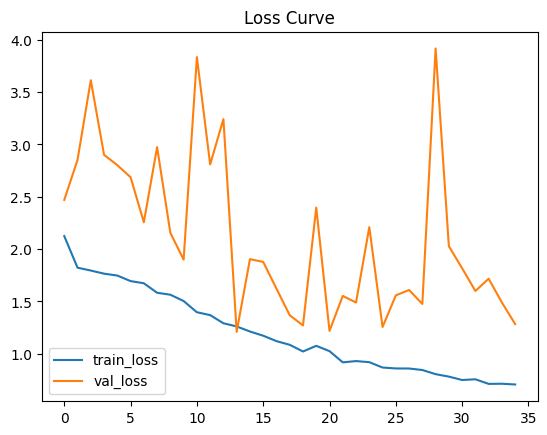

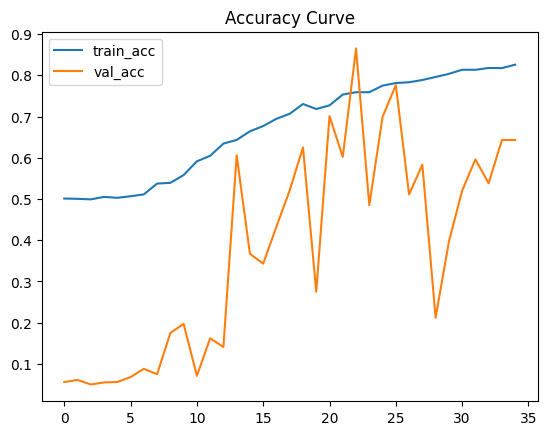

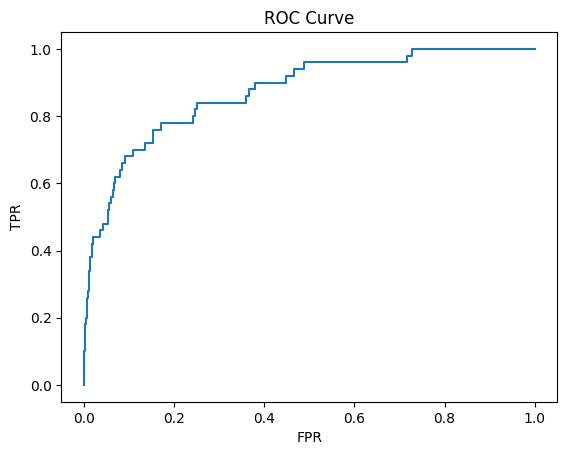

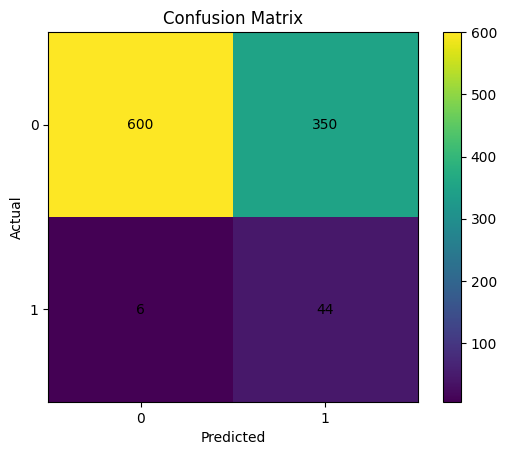

In [14]:
# =====================
# 10. VISUALIZATION
# =====================
plt.figure()
plt.plot(history['train_loss'], label='train_loss')
plt.plot(history['val_loss'], label='val_loss')
plt.legend()
plt.title("Loss Curve")
plt.show()

plt.figure()
plt.plot(history['train_acc'], label='train_acc')
plt.plot(history['val_acc'], label='val_acc')
plt.legend()
plt.title("Accuracy Curve")
plt.show()

fpr, tpr, _ = roc_curve(labels, preds)
plt.figure()
plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

cm = confusion_matrix(labels, preds_binary)
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

# Add numbers inside each cell
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks([0,1])
plt.yticks([0,1])
plt.show()


## 12. Analyze Misclassified Cases

Collect all images that the model classified incorrectly.
Display a grid of failed test cases with their predicted and true labels.
This helps identify patterns in model errors and potential data issues.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9764706..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.92156863..0.99215686].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.9764706].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.9764706].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9137255..0.99215686].
Clipping input data to t

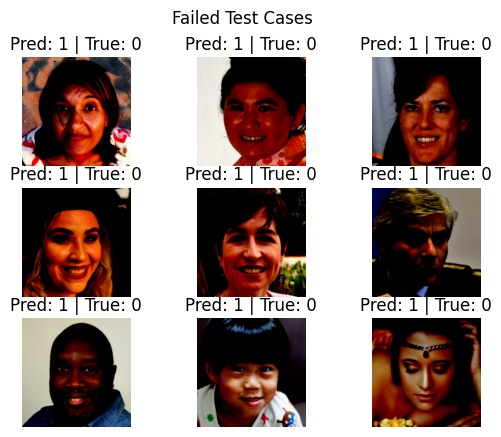

In [15]:
model.eval()
failed_images = []
failed_preds = []
failed_labels = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        out = model(x)
        probs = torch.sigmoid(out)
        preds_batch = (probs > 0.5).long().squeeze()

        for i in range(len(x)):
            if preds_batch[i] != y[i]:
                failed_images.append(x[i].cpu())
                failed_preds.append(preds_batch[i].item())
                failed_labels.append(y[i].item())

# Show up to 9 failed cases
num_show = min(9, len(failed_images))
plt.figure()
for i in range(num_show):
    plt.subplot(3, 3, i+1)
    img = failed_images[i].permute(1, 2, 0).numpy()
    plt.imshow(img)
    plt.title(f"Pred: {failed_preds[i]} | True: {failed_labels[i]}")
    plt.axis('off')

plt.suptitle("Failed Test Cases")
plt.show()
